<a href="https://colab.research.google.com/github/triman1905/100-days-of-machine-learning/blob/main/ML_RP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being s


CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     63671
           1       0.00      0.00      0.00     15535

    accuracy                           0.80     79206
   macro avg       0.40      0.50      0.45     79206
weighted avg       0.65      0.80      0.72     79206



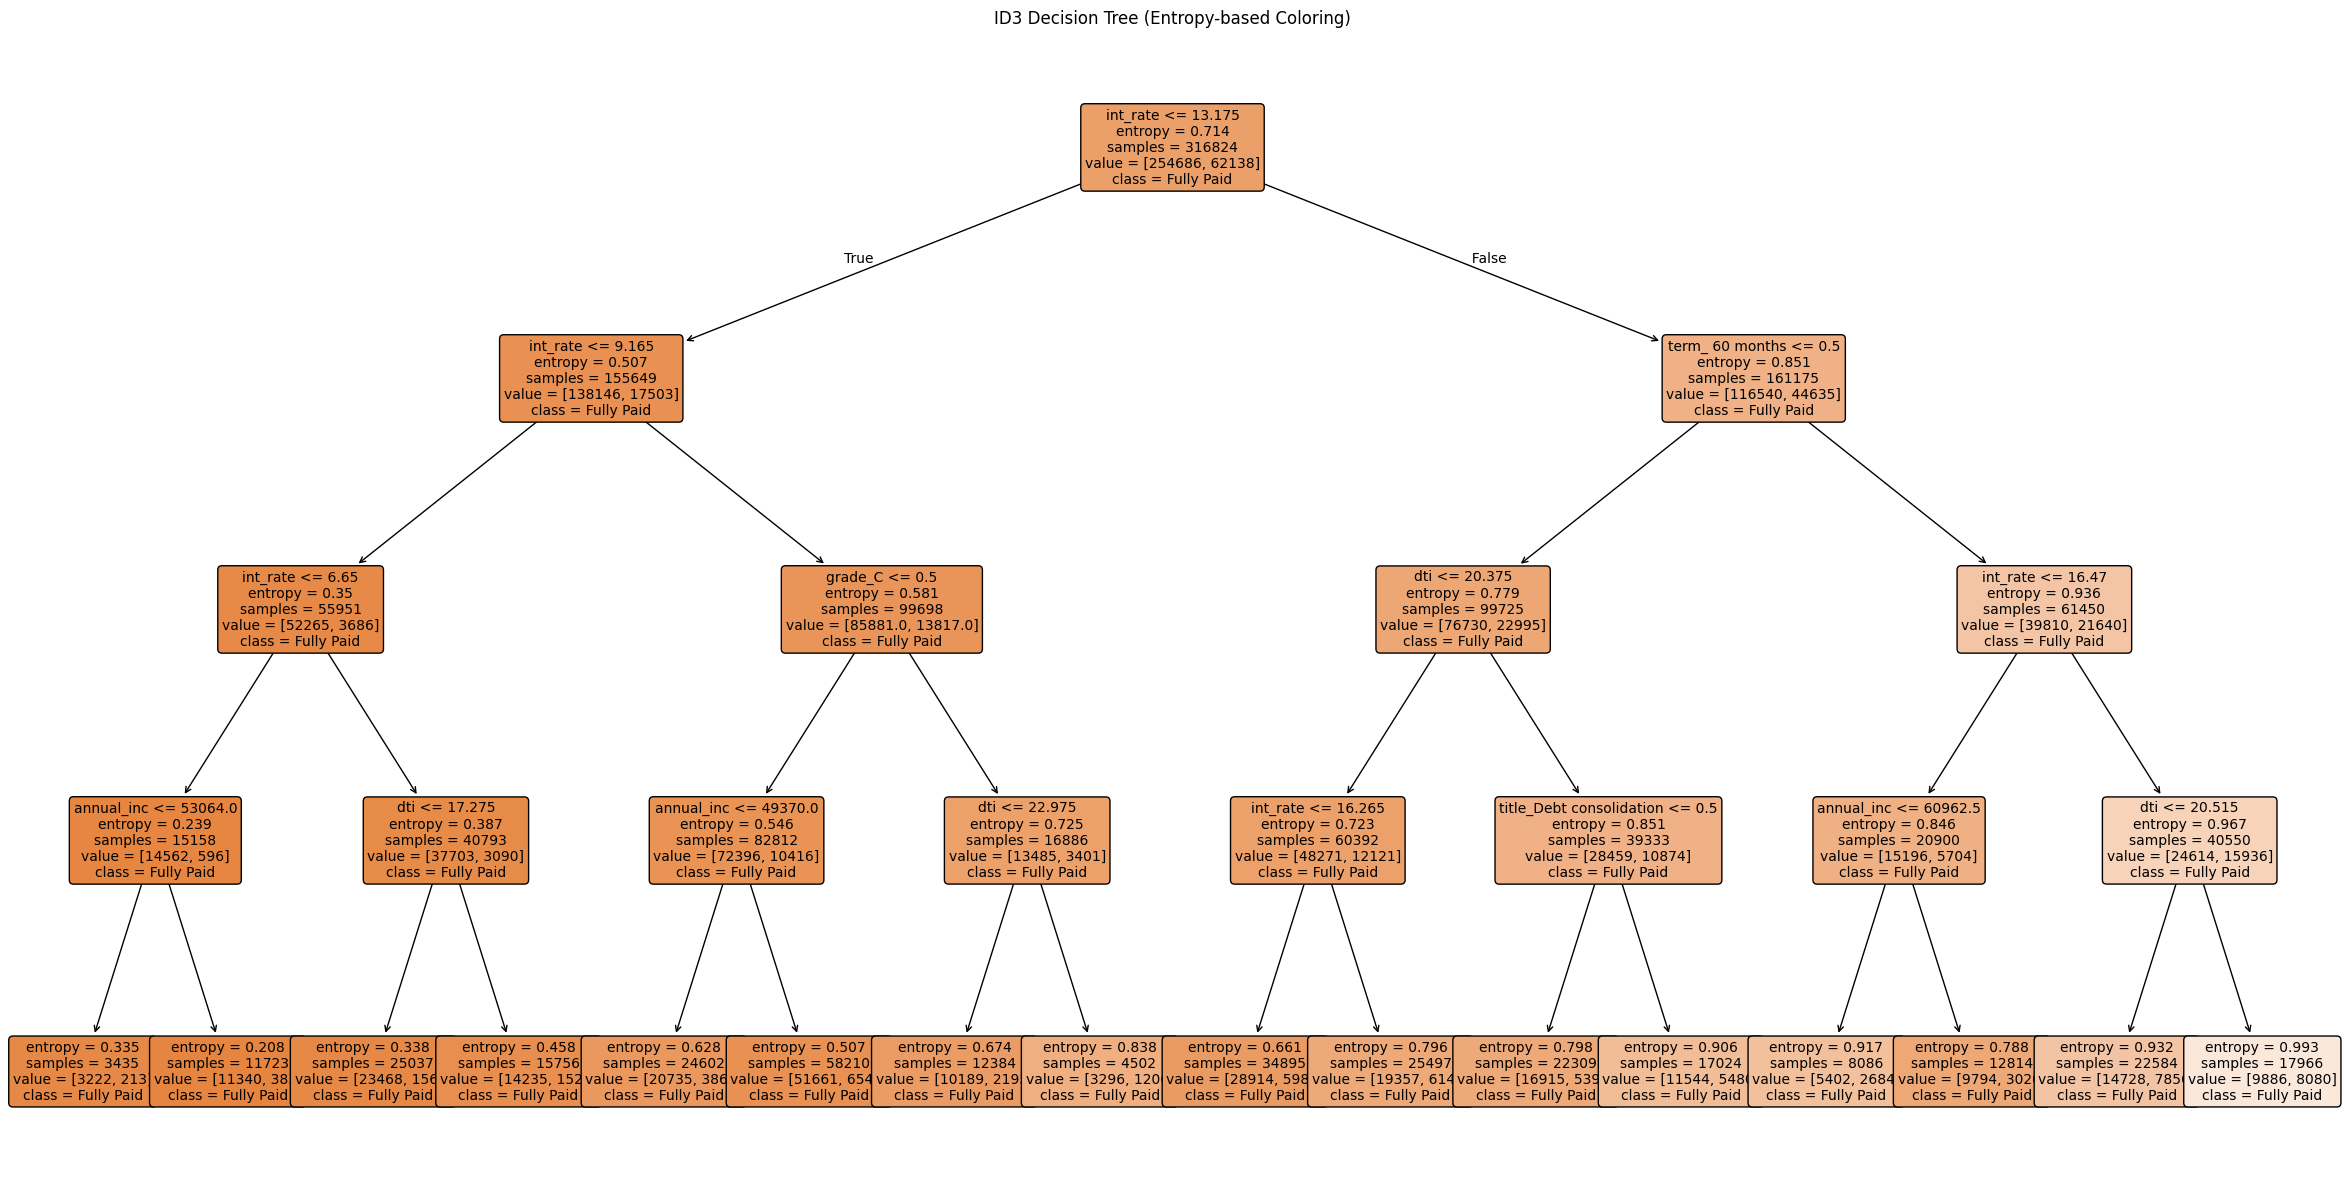

In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("lending_club_loan_two.csv")

# =========================
# 3. TARGET VARIABLE
# =========================
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})
df.drop("loan_status", axis=1, inplace=True)

# =========================
# 4. DROP HIGH CARDINALITY
# =========================
df.drop(["emp_title", "address"], axis=1, inplace=True)

# =========================
# 5. FEATURES & TARGET
# =========================
X = df.drop("target", axis=1)
y = df["target"]

# =========================
# 6. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 7. COLUMN TYPES
# =========================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# =========================
# 8. PREPROCESSING
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# =========================
# 9. ID3 DECISION TREE
# =========================
model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",      # ID3
        max_depth=4,
        min_samples_leaf=50,      # smoother color transitions
        class_weight={0: 1, 1: 1},
        random_state=42
    ))
])

# =========================
# 10. TRAIN MODEL
# =========================
model.fit(X_train, y_train)

# =========================
# 11. BASIC EVALUATION
# =========================
y_pred = model.predict(X_test)
print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred))

# =========================
# 12. PLOT TREE WITH COLOR GRADIENT
# =========================
preprocessor_fitted = model.named_steps["preprocess"]

num_features = num_cols.tolist()
cat_features = preprocessor_fitted.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(cat_cols)

feature_names = np.concatenate([num_features, cat_features])

tree_model = model.named_steps["classifier"]

plt.figure(figsize=(30, 15))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Fully Paid", "Charged Off"],
    filled=True,          # IMPORTANT for colors
    rounded=True,
    impurity=True,
    fontsize=10
)
plt.title("ID3 Decision Tree (Entropy-based Coloring)")
plt.show()

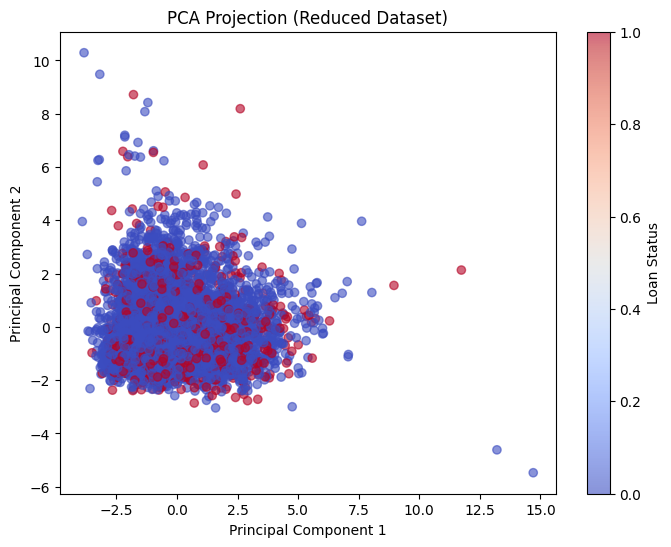

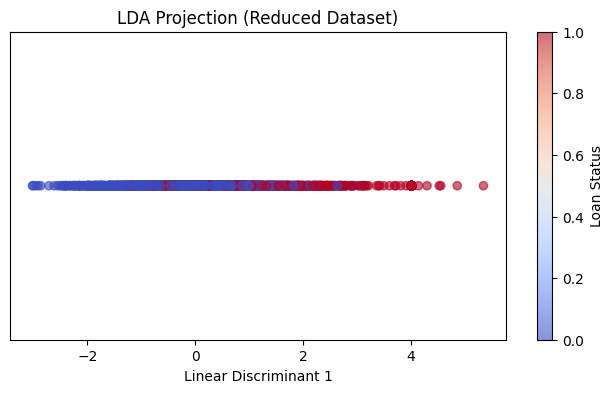

In [2]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("lending_club_loan_two.csv")

# =========================
# 3. TAKE RANDOM SMALL SAMPLE
# =========================
df = df.sample(n=5000, random_state=42)

# =========================
# 4. CREATE TARGET VARIABLE
# =========================
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

df.drop("loan_status", axis=1, inplace=True)

# =========================
# 5. DROP HIGH CARDINALITY COLUMNS
# =========================
df.drop(["emp_title", "address"], axis=1, inplace=True)

# =========================
# 6. SPLIT FEATURES & TARGET
# =========================
X = df.drop("target", axis=1)
y = df["target"]

# =========================
# 7. IDENTIFY COLUMN TYPES
# =========================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# =========================
# 8. PREPROCESSING
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# =========================
# 9. TRANSFORM DATA
# =========================
X_processed = preprocessor.fit_transform(X)

# Convert sparse to dense if needed
X_processed = X_processed.toarray()

# =========================
# 10. APPLY PCA
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# =========================
# 11. APPLY LDA
# =========================
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_processed, y)

# =========================
# 12. PCA VISUALIZATION
# =========================
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm", alpha=0.6)
plt.title("PCA Projection (Reduced Dataset)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Loan Status")
plt.show()

# =========================
# 13. LDA VISUALIZATION
# =========================
plt.figure(figsize=(8,4))
plt.scatter(X_lda[:,0], np.zeros_like(X_lda), c=y, cmap="coolwarm", alpha=0.6)
plt.title("LDA Projection (Reduced Dataset)")
plt.xlabel("Linear Discriminant 1")
plt.yticks([])
plt.colorbar(label="Loan Status")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


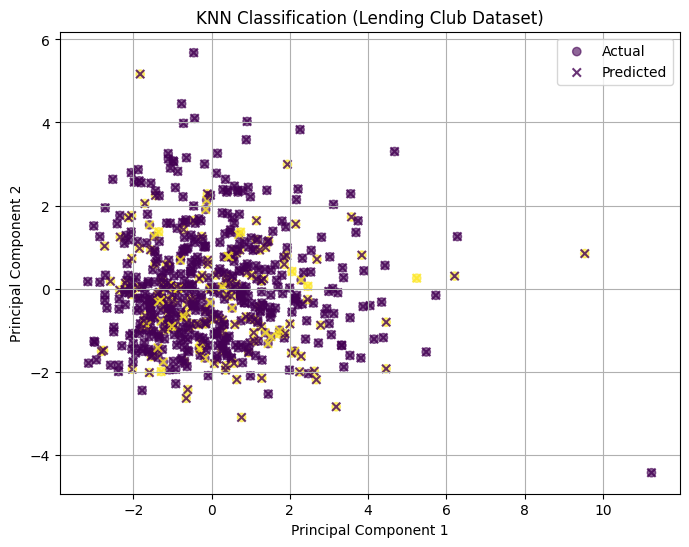

In [3]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("lending_club_loan_two.csv")

# =========================
# 3. TAKE SMALL SAMPLE
# =========================
df = df.sample(n=2000, random_state=42)

# =========================
# 4. TARGET VARIABLE
# =========================
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})
df.drop("loan_status", axis=1, inplace=True)

# =========================
# 5. DROP HIGH CARDINALITY
# =========================
df.drop(["emp_title", "address"], axis=1, inplace=True)

# =========================
# 6. FEATURES & TARGET
# =========================
X = df.drop("target", axis=1)
y = df["target"]

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# =========================
# 8. COLUMN TYPES
# =========================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# =========================
# 9. PREPROCESSING
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# =========================
# 10. PROCESS DATA
# =========================
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

X_train_p = X_train_p.toarray()
X_test_p = X_test_p.toarray()

# =========================
# 11. APPLY PCA (2D)
# =========================
pca = PCA(n_components=2)

X_train_2D = pca.fit_transform(X_train_p)
X_test_2D = pca.transform(X_test_p)

# =========================
# 12. TRAIN KNN
# =========================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_2D, y_train)

# =========================
# 13. PREDICT
# =========================
y_pred = knn.predict(X_test_2D)

# =========================
# 14. PLOT GRAPH (LIKE IRIS)
# =========================
plt.figure(figsize=(8,6))

# Actual points
plt.scatter(
    X_test_2D[:, 0], X_test_2D[:, 1],
    c=y_test,
    marker='o',
    alpha=0.6,
    label="Actual"
)

# Predicted points
plt.scatter(
    X_test_2D[:, 0], X_test_2D[:, 1],
    c=y_pred,
    marker='x',
    alpha=0.8,
    label="Predicted"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KNN Classification (Lending Club Dataset)")
plt.legend()
plt.grid()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 7, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy: 0.7816666666666666


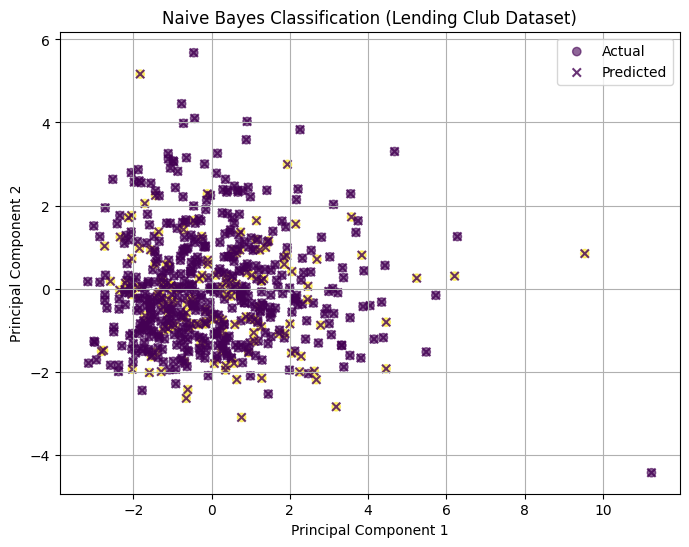

In [4]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("lending_club_loan_two.csv")

# =========================
# 3. TAKE SMALL SAMPLE
# =========================
df = df.sample(n=2000, random_state=42)

# =========================
# 4. TARGET VARIABLE
# =========================
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})
df.drop("loan_status", axis=1, inplace=True)

# =========================
# 5. DROP HIGH CARDINALITY
# =========================
df.drop(["emp_title", "address"], axis=1, inplace=True)

# =========================
# 6. FEATURES & TARGET
# =========================
X = df.drop("target", axis=1)
y = df["target"]

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# =========================
# 8. COLUMN TYPES
# =========================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# =========================
# 9. PREPROCESSING
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# =========================
# 10. PROCESS DATA
# =========================
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

X_train_p = X_train_p.toarray()
X_test_p = X_test_p.toarray()

# =========================
# 11. APPLY PCA (2D)
# =========================
pca = PCA(n_components=2)

X_train_2D = pca.fit_transform(X_train_p)
X_test_2D = pca.transform(X_test_p)

# =========================
# 12. TRAIN NAIVE BAYES
# =========================
nb = GaussianNB()
nb.fit(X_train_2D, y_train)

# =========================
# 13. PREDICT
# =========================
y_pred = nb.predict(X_test_2D)

# =========================
# 14. ACCURACY
# =========================
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# =========================
# 15. PLOT GRAPH
# =========================
plt.figure(figsize=(8,6))

# Actual
plt.scatter(
    X_test_2D[:, 0], X_test_2D[:, 1],
    c=y_test,
    marker='o',
    alpha=0.6,
    label="Actual"
)

# Predicted
plt.scatter(
    X_test_2D[:, 0], X_test_2D[:, 1],
    c=y_pred,
    marker='x',
    alpha=0.8,
    label="Predicted"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Naive Bayes Classification (Lending Club Dataset)")
plt.legend()
plt.grid()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 6, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== PERFORMANCE TABLE ===

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression     0.774   0.375000  0.129808  0.192857
1  Decision Tree (ID3)     0.785   0.294118  0.024038  0.044444
2            KNN (PCA)     0.753   0.180328  0.052885  0.081784
3          Naive Bayes     0.327   0.200000  0.745192  0.315361
4       LDA + Logistic     0.701   0.284360  0.288462  0.286396


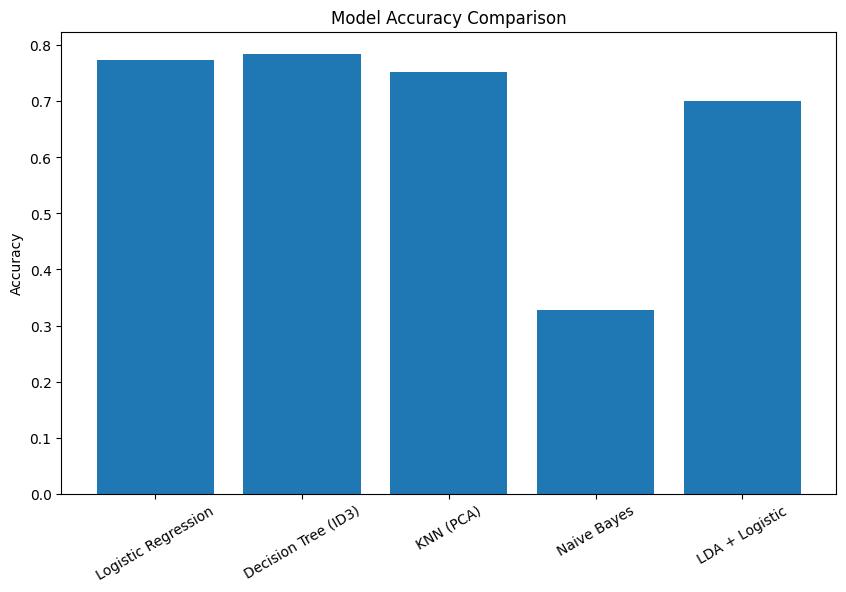

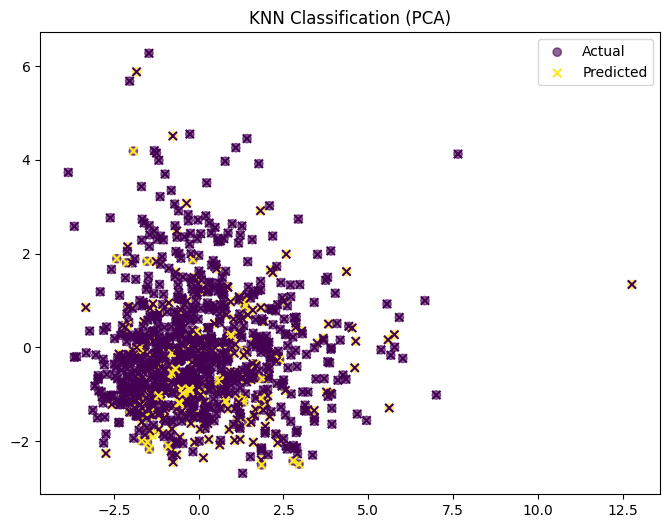

In [5]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.decomposition import PCA

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("lending_club_loan_two.csv", on_bad_lines='skip')

# Smaller dataset
df = df.sample(n=5000, random_state=42)

# =========================
# 3. TARGET VARIABLE
# =========================
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

df.drop(["loan_status", "emp_title", "address"], axis=1, inplace=True)

X = df.drop("target", axis=1)
y = df["target"]

# =========================
# 4. SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5. PREPROCESSING
# =========================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), cat_cols)
])

X_train_p = preprocessor.fit_transform(X_train).toarray()
X_test_p = preprocessor.transform(X_test).toarray()

# =========================
# 6. PCA FOR VISUALIZATION
# =========================
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train_p)
X_test_2D = pca.transform(X_test_p)

# =========================
# 7. MODEL FUNCTION
# =========================
def evaluate_model(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return [name, acc, prec, rec, f1, y_pred]

# =========================
# 8. TRAIN MODELS
# =========================
results = []

# Logistic Regression
results.append(evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000),
    X_train_p, X_test_p
))

# Decision Tree (ID3)
results.append(evaluate_model(
    "Decision Tree (ID3)",
    DecisionTreeClassifier(criterion="entropy", max_depth=4),
    X_train_p, X_test_p
))

# KNN (on PCA)
results.append(evaluate_model(
    "KNN (PCA)",
    KNeighborsClassifier(n_neighbors=5),
    X_train_2D, X_test_2D
))

# Naive Bayes
results.append(evaluate_model(
    "Naive Bayes",
    GaussianNB(),
    X_train_p, X_test_p
))

# LDA + Logistic
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_p, y_train)
X_test_lda = lda.transform(X_test_p)

results.append(evaluate_model(
    "LDA + Logistic",
    LogisticRegression(),
    X_train_lda, X_test_lda
))

# =========================
# 9. CREATE TABLE
# =========================
df_results = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1", "Pred"
])

print("\n=== PERFORMANCE TABLE ===\n")
print(df_results.drop("Pred", axis=1))

# =========================
# 10. BAR GRAPH
# =========================
plt.figure(figsize=(10,6))

models = df_results["Model"]
accuracy = df_results["Accuracy"]

plt.bar(models, accuracy)
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

# =========================
# 11. PCA SCATTER (KNN)
# =========================
y_pred_knn = results[2][5]

plt.figure(figsize=(8,6))

plt.scatter(X_test_2D[:,0], X_test_2D[:,1],
            c=y_test, alpha=0.6, label="Actual")

plt.scatter(X_test_2D[:,0], X_test_2D[:,1],
            c=y_pred_knn, marker='x', label="Predicted")

plt.title("KNN Classification (PCA)")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 6, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



=== PERFORMANCE TABLE ===

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression     0.774   0.375000  0.129808  0.192857
1  Decision Tree (ID3)     0.785   0.294118  0.024038  0.044444
2            KNN (PCA)     0.753   0.180328  0.052885  0.081784
3          Naive Bayes     0.327   0.200000  0.745192  0.315361
4       LDA + Logistic     0.701   0.284360  0.288462  0.286396


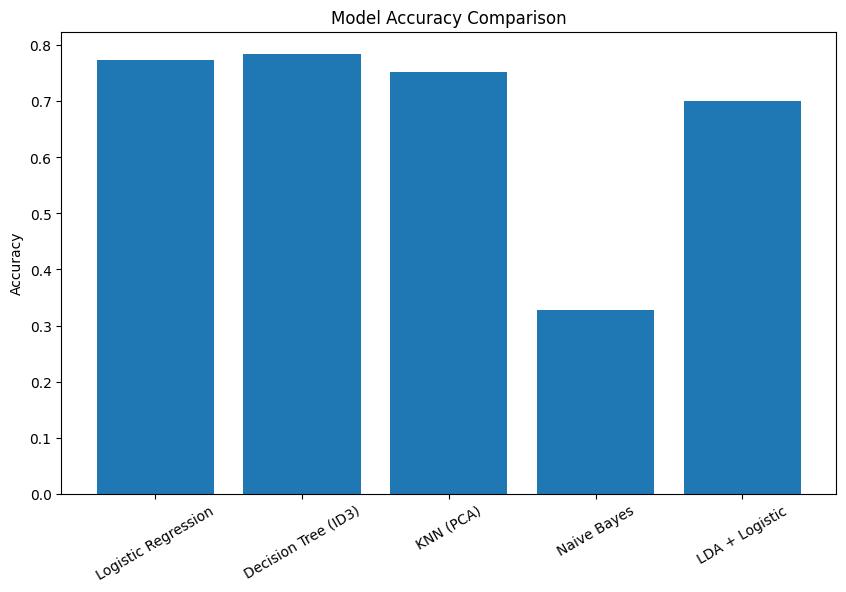

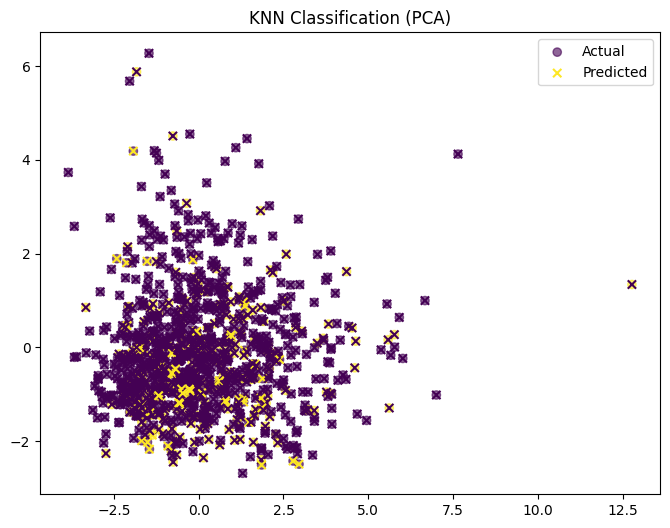

In [6]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.decomposition import PCA

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("lending_club_loan_two.csv", on_bad_lines='skip')

# Smaller dataset
df = df.sample(n=5000, random_state=42)

# =========================
# 3. TARGET VARIABLE
# =========================
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

df.drop(["loan_status", "emp_title", "address"], axis=1, inplace=True)

X = df.drop("target", axis=1)
y = df["target"]

# =========================
# 4. SPLIT DATA
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 5. PREPROCESSING
# =========================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]), cat_cols)
])

X_train_p = preprocessor.fit_transform(X_train).toarray()
X_test_p = preprocessor.transform(X_test).toarray()

# =========================
# 6. PCA FOR VISUALIZATION
# =========================
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train_p)
X_test_2D = pca.transform(X_test_p)

# =========================
# 7. MODEL FUNCTION
# =========================
def evaluate_model(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return [name, acc, prec, rec, f1, y_pred]

# =========================
# 8. TRAIN MODELS
# =========================
results = []

# Logistic Regression
results.append(evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000),
    X_train_p, X_test_p
))

# Decision Tree (ID3)
results.append(evaluate_model(
    "Decision Tree (ID3)",
    DecisionTreeClassifier(criterion="entropy", max_depth=4),
    X_train_p, X_test_p
))

# KNN (on PCA)
results.append(evaluate_model(
    "KNN (PCA)",
    KNeighborsClassifier(n_neighbors=5),
    X_train_2D, X_test_2D
))

# Naive Bayes
results.append(evaluate_model(
    "Naive Bayes",
    GaussianNB(),
    X_train_p, X_test_p
))

# LDA + Logistic
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_p, y_train)
X_test_lda = lda.transform(X_test_p)

results.append(evaluate_model(
    "LDA + Logistic",
    LogisticRegression(),
    X_train_lda, X_test_lda
))

# =========================
# 9. CREATE TABLE
# =========================
df_results = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1", "Pred"
])

print("\n=== PERFORMANCE TABLE ===\n")
print(df_results.drop("Pred", axis=1))

# =========================
# 10. BAR GRAPH
# =========================
plt.figure(figsize=(10,6))

models = df_results["Model"]
accuracy = df_results["Accuracy"]

plt.bar(models, accuracy)
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

# =========================
# 11. PCA SCATTER (KNN)
# =========================
y_pred_knn = results[2][5]

plt.figure(figsize=(8,6))

plt.scatter(X_test_2D[:,0], X_test_2D[:,1],
            c=y_test, alpha=0.6, label="Actual")

plt.scatter(X_test_2D[:,0], X_test_2D[:,1],
            c=y_pred_knn, marker='x', label="Predicted")

plt.title("KNN Classification (PCA)")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy: 0.796
Precision: 0.4731182795698925
Recall: 0.10918114143920596
F1: 0.1774193548387097


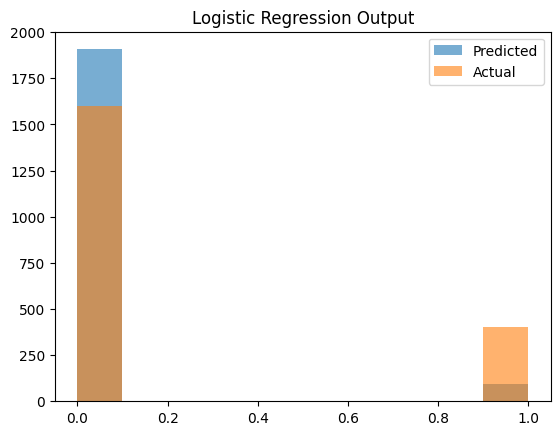

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load
df = pd.read_csv("lending_club_loan_two.csv", on_bad_lines='skip')
df = df.sample(n=10000, random_state=42)

df["target"] = df["loan_status"].map({"Fully Paid":0, "Charged Off":1})
df.drop(["loan_status","emp_title","address"], axis=1, inplace=True)

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)

cat = X.select_dtypes(include="object").columns
num = X.select_dtypes(exclude="object").columns

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(drop="first", handle_unknown="ignore"))]), cat)
])

X_train = pre.fit_transform(X_train).toarray()
X_test = pre.transform(X_test).toarray()

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))

# Graph
plt.hist(y_pred, alpha=0.6, label="Predicted")
plt.hist(y_test, alpha=0.6, label="Actual")
plt.legend()
plt.title("Logistic Regression Output")
plt.show()

In [14]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("lending_club_loan_two.csv")

# =========================
# 3. TAKE 10K SAMPLE
# =========================
df = df.sample(n=30000, random_state=42)

# =========================
# 4. TARGET VARIABLE
# =========================
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

df.drop("loan_status", axis=1, inplace=True)

# =========================
# 5. DROP HIGH CARDINALITY
# =========================
df.drop(["emp_title", "address"], axis=1, inplace=True)

# =========================
# 6. SPLIT FEATURES & TARGET
# =========================
X = df.drop("target", axis=1)
y = df["target"]

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# =========================
# 8. COLUMN TYPES
# =========================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# =========================
# 9. PREPROCESSING PIPELINE
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# =========================
# 10. TRANSFORM DATA
# =========================
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

X_train_p = X_train_p.toarray()
X_test_p = X_test_p.toarray()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [15]:
from sklearn.linear_model import LogisticRegression

# =========================
# 11. TRAIN MODEL
# =========================
model = LogisticRegression(max_iter=1000)
model.fit(X_train_p, y_train)

# =========================
# 12. PREDICTION
# =========================
y_pred = model.predict(X_test_p)
y_prob = model.predict_proba(X_test_p)[:,1]

# =========================
# 13. METRICS
# =========================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

Accuracy: 0.8013333333333333
Precision: 0.4894179894179894
Recall: 0.10393258426966293
F1 Score: 0.17145505097312327


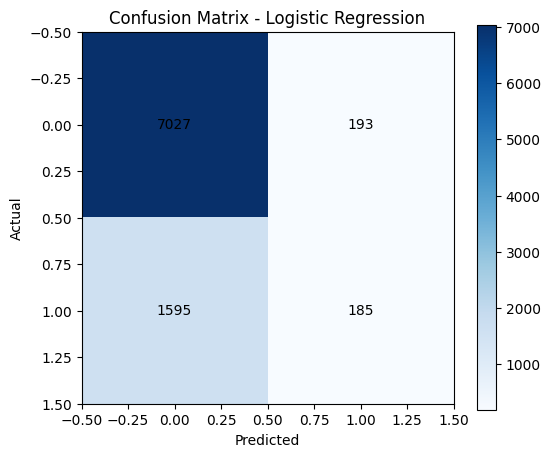

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

DECISION TREE


In [17]:
from sklearn.tree import DecisionTreeClassifier

# ID3 uses entropy
dt = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)

dt.fit(X_train_p, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [18]:
y_pred = dt.predict(X_test_p)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

Accuracy: 0.7985555555555556
Precision: 0.4492307692307692
Recall: 0.08202247191011236
F1 Score: 0.13871733966745844


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



===== DECISION TREE (ID3 - OPTIMIZED) =====
Accuracy: 63.93%
Precision: 28.88%
Recall: 55.53%
F1 Score: 37.99%

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.86      0.66      0.75      4806
           1       0.29      0.56      0.38      1194

    accuracy                           0.64      6000
   macro avg       0.57      0.61      0.56      6000
weighted avg       0.74      0.64      0.67      6000



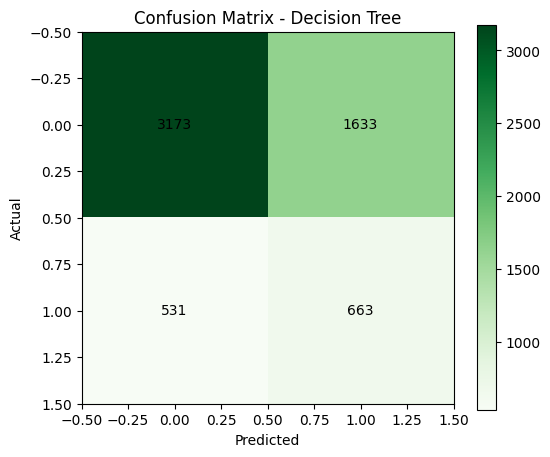

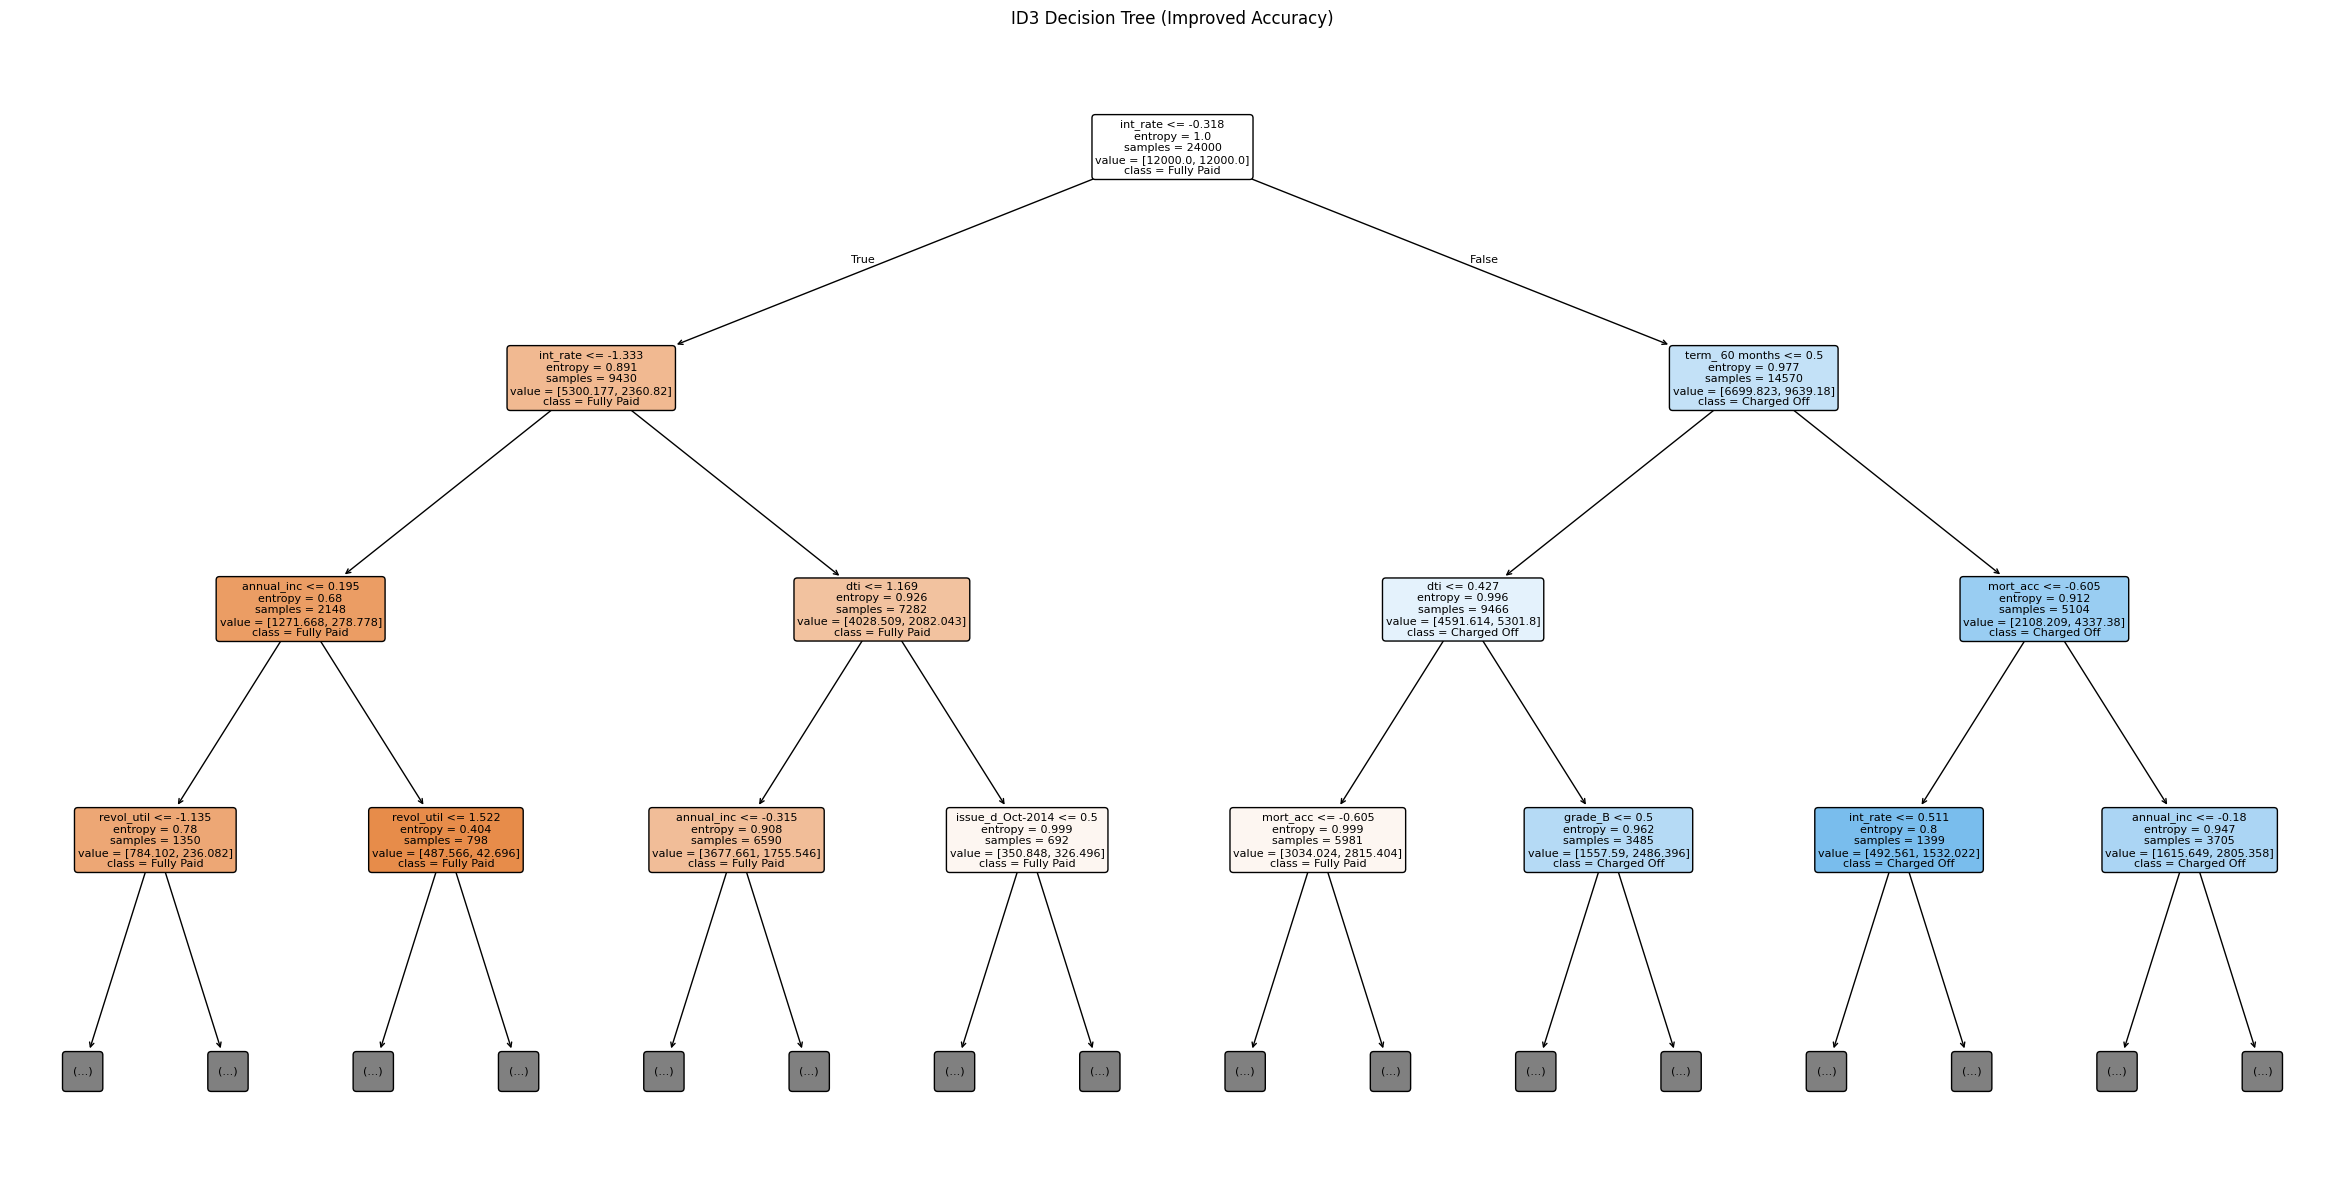

In [23]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("lending_club_loan_two.csv")

# =========================
# 3. TAKE 30K SAMPLE
# =========================
df = df.sample(n=30000, random_state=42)

# =========================
# 4. TARGET VARIABLE
# =========================
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})
df.drop("loan_status", axis=1, inplace=True)

# =========================
# 5. DROP HIGH CARDINALITY
# =========================
df.drop(["emp_title", "address"], axis=1, inplace=True)

# =========================
# 6. FEATURES & TARGET
# =========================
X = df.drop("target", axis=1)
y = df["target"]

# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 8. COLUMN TYPES
# =========================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# =========================
# 9. PREPROCESSING (IMPROVED)
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())   # improves splits
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# =========================
# 10. DECISION TREE (OPTIMIZED ID3)
# =========================
model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="entropy",        # ID3
        max_depth=15,
        min_samples_leaf=5,
        min_samples_split=20,
        class_weight="balanced",    # handles imbalance
        random_state=42
    ))
])

# =========================
# 11. TRAIN MODEL
# =========================
model.fit(X_train, y_train)

# =========================
# 12. PREDICTIONS
# =========================
y_pred = model.predict(X_test)

# =========================
# 13. METRICS
# =========================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== DECISION TREE (ID3 - OPTIMIZED) =====")
print("Accuracy: %.2f%%" % (acc * 100))
print("Precision: %.2f%%" % (prec * 100))
print("Recall: %.2f%%" % (rec * 100))
print("F1 Score: %.2f%%" % (f1 * 100))

print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred))

# =========================
# 14. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 15. TREE VISUALIZATION
# =========================
preprocessor_fitted = model.named_steps["preprocess"]

num_features = num_cols.tolist()
cat_features = preprocessor_fitted.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(cat_cols)

feature_names = np.concatenate([num_features, cat_features])

tree_model = model.named_steps["classifier"]

plt.figure(figsize=(30, 15))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Fully Paid", "Charged Off"],
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=8,
    max_depth=3   # keep readable
)

plt.title("ID3 Decision Tree (Improved Accuracy)")
plt.show()

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("lending_club_loan_two.csv")

# =========================
# 3. SAMPLE 30K
# =========================
df = df.sample(n=10000, random_state=42)

# =========================
# 4. TARGET
# =========================
df["target"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})
df.drop("loan_status", axis=1, inplace=True)

# =========================
# 5. DROP HIGH CARDINALITY
# =========================
df.drop(["emp_title", "address"], axis=1, inplace=True)

# =========================
# 6. SPLIT
# =========================
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 7. COLUMN TYPES
# =========================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

# =========================
# 8. PREPROCESSING
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Transform
X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)

X_train_p = X_train_p.toarray()
X_test_p = X_test_p.toarray()

# =========================
# 9. GRID SEARCH (BEST K)
# =========================
param_grid = {
    "n_neighbors": [5,7,9,11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_p, y_train)

knn = grid.best_estimator_

# =========================
# 10. PREDICTION
# =========================
y_pred = knn.predict(X_test_p)

# =========================
# 11. METRICS
# =========================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== KNN (OPTIMIZED) =====")
print("Best Parameters:", grid.best_params_)
print("Accuracy: %.2f%%" % (acc * 100))
print("Precision: %.2f%%" % (prec * 100))
print("Recall: %.2f%%" % (rec * 100))
print("F1 Score: %.2f%%" % (f1 * 100))

print("\nCLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred))

# =========================
# 12. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 13. PCA ONLY FOR GRAPH
# =========================
pca = PCA(n_components=2)

X_test_2D = pca.fit_transform(X_test_p)

plt.figure(figsize=(8,6))

# Actual
plt.scatter(X_test_2D[:,0], X_test_2D[:,1],
            c=y_test, marker='o', alpha=0.5, label="Actual")

# Predicted
plt.scatter(X_test_2D[:,0], X_test_2D[:,1],
            c=y_pred, marker='x', alpha=0.7, label="Predicted")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KNN (Optimized) - Visualization")
plt.legend()
plt.grid()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 8, 9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
